# Nassau Candy Distributor — Analysis

This notebook contains the exploratory analysis, visualizations, results, and findings already completed for the project. Cleaning is kept in `src/data_cleaning.py`.

**Data-quality note:** the supplied dates produce unusually large calendar differences (904–1642 days). The source dates are retained without alteration, and Lead Time is treated as a limitation rather than a normal shipping-duration KPI.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path


project_root = Path.cwd().parent
sys.path.append(str(project_root))
from src.data_cleaning import load_data, clean_data
from src.feature_engineering import engineer_features
df = clean_data(load_data(r'D:\nassau-candy-project\data\shipping_data.csv'))


In [3]:
df.shape

(10194, 19)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

## 1. Dataset Overview

In [5]:
print('Shape:', df.shape)
df.head()
df.info()


Shape: (10194, 19)
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       

In [8]:
df.isnull().sum()
df.describe()


,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost,Lead Time
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538,2028-10-23 23:20:43.790465,134468.961154,13.908537,3.791838,9.166451,4.742087,1320.841868
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000,904.000000
25%,2549.250000,2024-09-28 00:00:00,2027-11-09 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000,1271.000000
50%,5097.500000,2025-04-06 12:00:00,2028-12-18 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000,1274.000000
75%,7645.750000,2025-09-16 00:00:00,2029-11-08 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000,1638.000000
max,10194.000000,2025-12-31 00:00:00,2030-06-28 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000,1642.000000
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647,262.444892


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 2. Date and Lead-Time Analysis

In [9]:
print('Order years:')
print(df['Order Date'].dt.year.value_counts().sort_index())
print('\nShip years:')
print(df['Ship Date'].dt.year.value_counts().sort_index())
print('\nLead time:')
print(df['Lead Time'].describe())


Order years:
Order Date
2024    4181
2025    6013
Name: count, dtype: int64

Ship years:
Ship Date
2026     711
2027    2089
2028    2367
2029    2899
2030    2128
Name: count, dtype: int64

Lead time:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


In [10]:
df['Lead Time'].value_counts().head(20)


Lead Time
1273    1326
1274    1035
1639     896
1640     657
1275     612
1271     610
908      591
909      519
1272     456
1637     449
1638     411
1641     397
1276     293
906      289
1269     258
910      207
1642     197
1636     190
1635     179
907      176
Name: count, dtype: int64

Observed lead-time summary: count 10,194; mean 1320.84; std 262.44; minimum 904; median 1274; maximum 1642 days. These values are unusually large for shipping and should be reported as a source-data limitation.

## 3. Factory Mapping and Distribution

Factory mapping is a feature-engineering step. The completed analysis used the following mapping, including the source spelling `Wonka Bar -Scrumdiddlyumptious`:

- Lot's O' Nuts: Nutty Crunch Surprise, Fudge Mallows, Scrumdiddlyumptious
- Wicked Choccy's: Milk Chocolate, Triple Dazzle Caramel
- Sugar Shack: Laffy Taffy, SweeTARTS, Nerds, Fun Dip, Fizzy Lifting Drinks
- Secret Factory: Everlasting Gobstopper, Lickable Wallpaper, Wonka Gum
- The Other Factory: Hair Toffee, Kazookles


In [11]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar - Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",

    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",

    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",

    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory"
}

df["Factory"] = df["Product Name"].map(factory_mapping)
df['Factory'].value_counts()


Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

In [12]:
df["Factory"].isnull().sum()

np.int64(0)

In [13]:
factory_summary = df['Factory'].value_counts().reset_index()
factory_summary.columns = ['Factory','Shipments']
factory_summary['Share_%'] = factory_summary['Shipments'] / len(df) * 100
factory_summary


,Factory,Shipments,Share_%
0,Lot's O' Nuts,5692,55.836767
1,Wicked Choccy's,4152,40.729841
2,Secret Factory,217,2.128703
3,The Other Factory,100,0.980969
4,Sugar Shack,33,0.323720


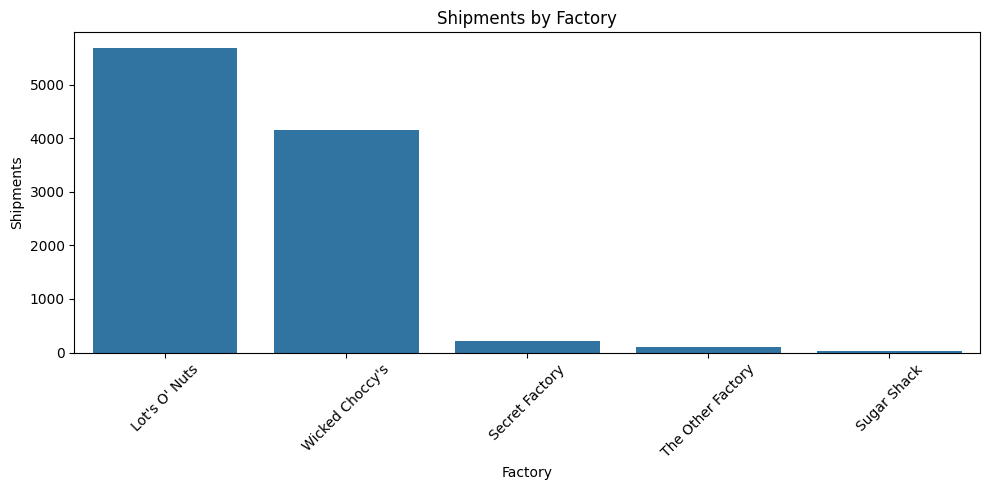

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(data=factory_summary, x='Factory', y='Shipments')
plt.xticks(rotation=45)
plt.title('Shipments by Factory')
plt.tight_layout()
plt.show()


In [15]:
factory_distribution = (
    df["Factory"]
    .value_counts()
    .reset_index()
)

factory_distribution.columns = ["Factory", "Shipments"]

factory_distribution

,Factory,Shipments
0,Lot's O' Nuts,5692
1,Wicked Choccy's,4152
2,Secret Factory,217
3,The Other Factory,100
4,Sugar Shack,33


In [16]:
factory_distribution["Percentage"] = (
    factory_distribution["Shipments"]
    / factory_distribution["Shipments"].sum()
    * 100
)

factory_distribution

,Factory,Shipments,Percentage
0,Lot's O' Nuts,5692,55.836767
1,Wicked Choccy's,4152,40.729841
2,Secret Factory,217,2.128703
3,The Other Factory,100,0.980969
4,Sugar Shack,33,0.323720


## 4. Factory Coordinates and Routes

In [17]:
factory_coordinates = {
    "Lot's O' Nuts": {
        "Latitude": 32.881893,
        "Longitude": -111.768036
    },
    "Wicked Choccy's": {
        "Latitude": 32.076176,
        "Longitude": -81.088371
    },
    "Sugar Shack": {
        "Latitude": 48.11914,
        "Longitude": -96.18115
    },
    "Secret Factory": {
        "Latitude": 41.446333,
        "Longitude": -90.565487
    },
    "The Other Factory": {
        "Latitude": 35.1175,
        "Longitude": -89.971107
    }
}
df['Factory Latitude'] = df['Factory'].map(lambda x: factory_coordinates[x]['Latitude'])
df['Factory Longitude'] = df['Factory'].map(lambda x: factory_coordinates[x]['Longitude'])
df['Route State'] = df['Factory'] + ' → ' + df['State/Province']
df['Route Region'] = df['Factory'] + ' → ' + df['Region']


In [18]:
df[[
    "Factory",
    "State/Province",
    "Route State"
]].head(10)

,Factory,State/Province,Route State
0,Wicked Choccy's,Texas,Wicked Choccy's → Texas
1,Wicked Choccy's,Illinois,Wicked Choccy's → Illinois
2,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
3,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
4,Wicked Choccy's,Pennsylvania,Wicked Choccy's → Pennsylvania
5,Lot's O' Nuts,Kentucky,Lot's O' Nuts → Kentucky
6,Wicked Choccy's,Kentucky,Wicked Choccy's → Kentucky
7,Wicked Choccy's,Georgia,Wicked Choccy's → Georgia
8,Lot's O' Nuts,Kentucky,Lot's O' Nuts → Kentucky
9,Wicked Choccy's,Kentucky,Wicked Choccy's → Kentucky


## 5. Route Volume

In [19]:
route_volume = (
    df.groupby("Route State")
      .size()
      .reset_index(name="Total Shipments")
      .sort_values("Total Shipments", ascending=False)
)

route_volume.head(20)

,Route State,Total Shipments
5,Lot's O' Nuts → California,1125
144,Wicked Choccy's → California,823
34,Lot's O' Nuts → New York,645
49,Lot's O' Nuts → Texas,569
173,Wicked Choccy's → New York,436
189,Wicked Choccy's → Texas,388
42,Lot's O' Nuts → Pennsylvania,331
53,Lot's O' Nuts → Washington,269
13,Lot's O' Nuts → Illinois,267
38,Lot's O' Nuts → Ohio,262


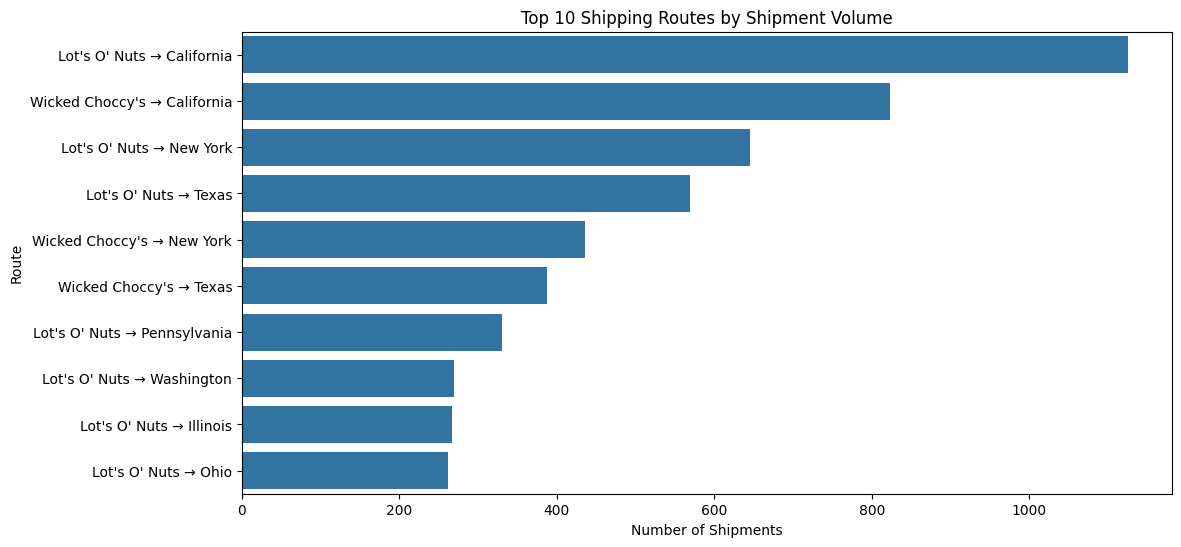

In [20]:
top_routes = route_volume.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_routes,
    x="Total Shipments",
    y="Route State"
)

plt.title("Top 10 Shipping Routes by Shipment Volume")
plt.xlabel("Number of Shipments")
plt.ylabel("Route")

plt.show()

Top routes from the completed analysis include: Lot's O' Nuts → California (1,125), Wicked Choccy's → California (823), Lot's O' Nuts → New York (645), Lot's O' Nuts → Texas (569), and Wicked Choccy's → New York (436).

## 6. Route Business Analysis

In [21]:
route_business = (df.groupby('Route State').agg(
    Total_Shipments=('Order ID','count'), Total_Sales=('Sales','sum'),
    Total_Units=('Units','sum'), Total_Gross_Profit=('Gross Profit','sum'),
    Total_Cost=('Cost','sum')).reset_index())
route_business['Profit_Margin_%'] = route_business['Total_Gross_Profit'] / route_business['Total_Sales'] * 100
route_business['Cost_Per_Shipment'] = route_business['Total_Cost'] / route_business['Total_Shipments']
route_business['Sales_Per_Shipment'] = route_business['Total_Sales'] / route_business['Total_Shipments']
route_business.head(20)


,Route State,Total_Shipments,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
0,Lot's O' Nuts → Alabama,34,475.61,133,326.91,148.7,68.734888,4.373529,13.988529
1,Lot's O' Nuts → Alberta,16,204.32,57,141.42,62.9,69.214957,3.931250,12.770000
2,Lot's O' Nuts → Arizona,111,1468.05,411,1013.15,454.9,69.013317,4.098198,13.225676
3,Lot's O' Nuts → Arkansas,31,434.69,122,299.69,135.0,68.943385,4.354839,14.022258
4,Lot's O' Nuts → British Columbia,18,253.40,71,173.80,79.6,68.587214,4.422222,14.077778
5,Lot's O' Nuts → California,1125,15044.90,4221,10401.00,4643.9,69.133062,4.127911,13.373244
6,Lot's O' Nuts → Colorado,103,1447.66,405,999.06,448.6,69.012061,4.355340,14.054951
7,Lot's O' Nuts → Connecticut,47,523.59,147,362.29,161.3,69.193453,3.431915,11.140213
8,Lot's O' Nuts → Delaware,43,631.59,177,436.19,195.4,69.062208,4.544186,14.688140
9,Lot's O' Nuts → District of Columbia,8,126.00,35,85.30,40.7,67.698413,5.087500,15.750000


The completed results show relatively consistent margins within factory groups. Therefore, cost per shipment or margin alone should not be used as proof of route inefficiency because product/factory mix also affects these metrics.

## 7. Shipping Mode Analysis

In [22]:
shipping_mode_summary = (df.groupby('Ship Mode').agg(
    Shipments=('Order ID','count'), Sales=('Sales','sum'), Units=('Units','sum'),
    Gross_Profit=('Gross Profit','sum'), Cost=('Cost','sum')).reset_index())
shipping_mode_summary['Profit_Margin_%'] = shipping_mode_summary['Gross_Profit'] / shipping_mode_summary['Sales'] * 100
shipping_mode_summary['Cost_Per_Shipment'] = shipping_mode_summary['Cost'] / shipping_mode_summary['Shipments']
shipping_mode_summary['Sales_Per_Shipment'] = shipping_mode_summary['Sales'] / shipping_mode_summary['Shipments']
shipping_mode_summary


,Ship Mode,Shipments,Sales,Units,Gross_Profit,Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
0,First Class,1548,21319.39,5724,14011.09,7308.30,65.719939,4.721124,13.772216
1,Same Day,547,7113.67,1975,4700.73,2412.94,66.080237,4.411225,13.004881
2,Second Class,1979,27860.22,7546,18306.52,9553.70,65.708455,4.827539,14.077928
3,Standard Class,6120,85490.35,23409,56424.46,29065.89,66.000970,4.749328,13.969011


Completed shipment counts: Standard Class 6,120; Second Class 1,979; First Class 1,548; Same Day 547. Standard Class is about 60% of shipments.

## 8. Route × Shipping Mode

In [23]:
route_mode = df.groupby(['Route State','Ship Mode']).size().reset_index(name='Shipments')
route_mode_pct = route_mode.copy()
route_mode_pct['Mode_Share_%'] = route_mode_pct['Shipments'] / route_mode_pct.groupby('Route State')['Shipments'].transform('sum') * 100
route_mode_pct.head(20)


,Route State,Ship Mode,Shipments,Mode_Share_%
0,Lot's O' Nuts → Alabama,First Class,4,11.764706
1,Lot's O' Nuts → Alabama,Second Class,8,23.529412
2,Lot's O' Nuts → Alabama,Standard Class,22,64.705882
3,Lot's O' Nuts → Alberta,Second Class,10,62.500000
4,Lot's O' Nuts → Alberta,Standard Class,6,37.500000
5,Lot's O' Nuts → Arizona,First Class,17,15.315315
6,Lot's O' Nuts → Arizona,Same Day,10,9.009009
7,Lot's O' Nuts → Arizona,Second Class,12,10.810811
8,Lot's O' Nuts → Arizona,Standard Class,72,64.864865
9,Lot's O' Nuts → Arkansas,First Class,5,16.129032


## 9. State/Province Analysis

In [24]:
locations = df['State/Province'].value_counts().reset_index()
locations.columns = ['State/Province','Shipments']
locations


,State/Province,Shipments
0,California,2001
1,New York,1128
2,Texas,985
3,Pennsylvania,587
4,Washington,506
5,Illinois,492
6,Ohio,469
7,Florida,383
8,Michigan,255
9,North Carolina,249


The dataset contains U.S. states and Canadian provinces. Because customer latitude/longitude is not supplied, any state/province centroid distance should be described as approximate geographic distance, not exact road distance.

## 10. Key Findings and Conclusion

- Lot's O' Nuts: 5,692 shipments (55.83%).
- Wicked Choccy's: 4,152 shipments (40.73%).
- The two largest factories account for approximately 96.56% of records.
- Lot's O' Nuts → California is the highest-volume route with 1,125 shipments.
- Standard Class has the most shipments (6,120).
- The supplied dates create an unusual 904–1,642 day Lead Time range; this is documented as a data-quality limitation.
- Financial route metrics should be interpreted with factory/product mix in mind.


In [25]:
route_business = (
    df.groupby("Route State")
      .agg(
          Total_Shipments=("Order ID", "count"),
          Total_Sales=("Sales", "sum"),
          Total_Units=("Units", "sum"),
          Total_Gross_Profit=("Gross Profit", "sum"),
          Total_Cost=("Cost", "sum")
      )
      .reset_index()
)

route_business.head()

,Route State,Total_Shipments,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
0,Lot's O' Nuts → Alabama,34,475.61,133,326.91,148.7
1,Lot's O' Nuts → Alberta,16,204.32,57,141.42,62.9
2,Lot's O' Nuts → Arizona,111,1468.05,411,1013.15,454.9
3,Lot's O' Nuts → Arkansas,31,434.69,122,299.69,135.0
4,Lot's O' Nuts → British Columbia,18,253.40,71,173.80,79.6


In [26]:
route_business["Profit_Margin_%"] = (
    route_business["Total_Gross_Profit"]
    / route_business["Total_Sales"]
    * 100
)

In [27]:
route_business["Cost_Per_Shipment"] = (
    route_business["Total_Cost"]
    / route_business["Total_Shipments"]
)

route_business["Sales_Per_Shipment"] = (
    route_business["Total_Sales"]
    / route_business["Total_Shipments"]
)

In [28]:
route_business.head(10)

,Route State,Total_Shipments,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
0,Lot's O' Nuts → Alabama,34,475.61,133,326.91,148.7,68.734888,4.373529,13.988529
1,Lot's O' Nuts → Alberta,16,204.32,57,141.42,62.9,69.214957,3.931250,12.770000
2,Lot's O' Nuts → Arizona,111,1468.05,411,1013.15,454.9,69.013317,4.098198,13.225676
3,Lot's O' Nuts → Arkansas,31,434.69,122,299.69,135.0,68.943385,4.354839,14.022258
4,Lot's O' Nuts → British Columbia,18,253.40,71,173.80,79.6,68.587214,4.422222,14.077778
5,Lot's O' Nuts → California,1125,15044.90,4221,10401.00,4643.9,69.133062,4.127911,13.373244
6,Lot's O' Nuts → Colorado,103,1447.66,405,999.06,448.6,69.012061,4.355340,14.054951
7,Lot's O' Nuts → Connecticut,47,523.59,147,362.29,161.3,69.193453,3.431915,11.140213
8,Lot's O' Nuts → Delaware,43,631.59,177,436.19,195.4,69.062208,4.544186,14.688140
9,Lot's O' Nuts → District of Columbia,8,126.00,35,85.30,40.7,67.698413,5.087500,15.750000


In [29]:
route_business_by_volume = (
    route_business
    .sort_values("Total_Shipments", ascending=False)
)

route_business_by_volume.head(10)

,Route State,Total_Shipments,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
5,Lot's O' Nuts → California,1125,15044.90,4221,10401.00,4643.90,69.133062,4.127911,13.373244
144,Wicked Choccy's → California,823,11394.00,3266,7421.32,3972.68,65.133579,4.827072,13.844471
34,Lot's O' Nuts → New York,645,8757.81,2455,6055.01,2702.80,69.138403,4.190388,13.578000
49,Lot's O' Nuts → Texas,569,7642.34,2142,5278.34,2364.00,69.067066,4.154657,13.431178
173,Wicked Choccy's → New York,436,5518.25,1583,3594.11,1924.14,65.131337,4.413165,12.656537
189,Wicked Choccy's → Texas,388,5140.50,1478,3347.74,1792.76,65.124793,4.620515,13.248711
42,Lot's O' Nuts → Pennsylvania,331,4338.55,1216,2993.65,1344.90,69.001164,4.063142,13.107402
53,Lot's O' Nuts → Washington,269,3492.91,980,2415.91,1077.00,69.166111,4.003717,12.984796
13,Lot's O' Nuts → Illinois,267,3539.21,995,2452.51,1086.70,69.295408,4.070037,13.255468
38,Lot's O' Nuts → Ohio,262,3472.74,974,2400.24,1072.50,69.116605,4.093511,13.254733


In [30]:
route_business[
    [
        "Route State",
        "Total_Shipments",
        "Total_Sales",
        "Total_Gross_Profit",
        "Profit_Margin_%"
    ]
].sort_values(
    "Profit_Margin_%",
    ascending=False
).head(10)

,Route State,Total_Shipments,Total_Sales,Total_Gross_Profit,Profit_Margin_%
129,The Other Factory → North Carolina,1,9.00,7.00,77.777778
56,Lot's O' Nuts → Wyoming,1,13.96,9.96,71.346705
30,Lot's O' Nuts → New Brunswick,4,97.72,69.72,71.346705
54,Lot's O' Nuts → West Virginia,2,38.72,27.42,70.816116
43,Lot's O' Nuts → Prince Edward Island,6,78.10,54.90,70.294494
51,Lot's O' Nuts → Vermont,5,103.19,72.39,70.152147
26,Lot's O' Nuts → Missouri,36,514.08,359.08,69.849051
21,Lot's O' Nuts → Maryland,60,812.74,567.54,69.830450
47,Lot's O' Nuts → South Dakota,9,117.59,82.09,69.810358
11,Lot's O' Nuts → Georgia,110,1474.09,1027.79,69.723694


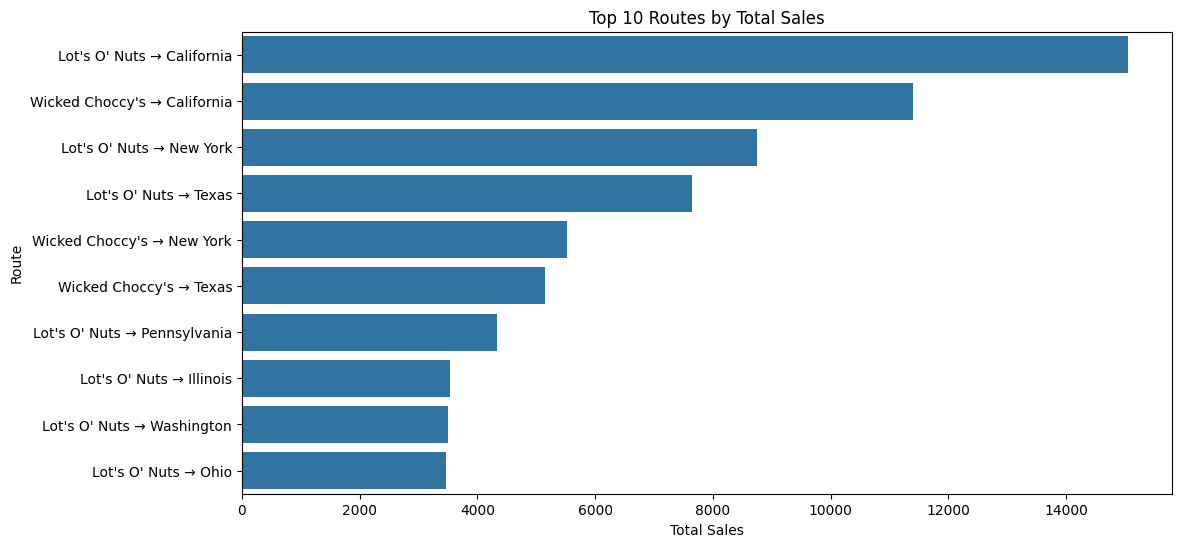

In [31]:
top_sales_routes = (
    route_business
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sales_routes,
    x="Total_Sales",
    y="Route State"
)

plt.title("Top 10 Routes by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Route")

plt.show()

In [32]:
shipping_mode_summary["Profit_Margin_%"] = (
    shipping_mode_summary["Gross_Profit"]
    / shipping_mode_summary["Sales"]
    * 100
)

shipping_mode_summary["Cost_Per_Shipment"] = (
    shipping_mode_summary["Cost"]
    / shipping_mode_summary["Shipments"]
)

shipping_mode_summary["Sales_Per_Shipment"] = (
    shipping_mode_summary["Sales"]
    / shipping_mode_summary["Shipments"]
)

In [33]:
shipping_mode_summary

,Ship Mode,Shipments,Sales,Units,Gross_Profit,Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
0,First Class,1548,21319.39,5724,14011.09,7308.30,65.719939,4.721124,13.772216
1,Same Day,547,7113.67,1975,4700.73,2412.94,66.080237,4.411225,13.004881
2,Second Class,1979,27860.22,7546,18306.52,9553.70,65.708455,4.827539,14.077928
3,Standard Class,6120,85490.35,23409,56424.46,29065.89,66.000970,4.749328,13.969011


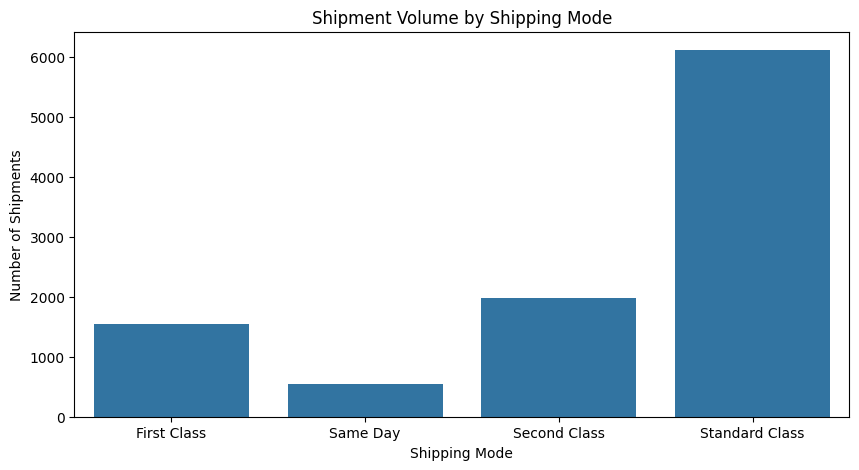

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=shipping_mode_summary,
    x="Ship Mode",
    y="Shipments"
)

plt.title("Shipment Volume by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Shipments")

plt.show()

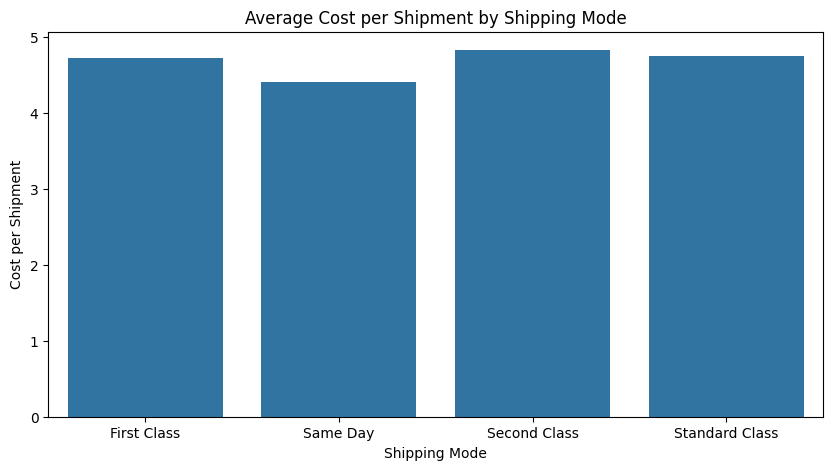

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=shipping_mode_summary,
    x="Ship Mode",
    y="Cost_Per_Shipment"
)

plt.title("Average Cost per Shipment by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Cost per Shipment")

plt.show()

In [36]:
route_mode = (
    df.groupby(["Route State", "Ship Mode"])
      .size()
      .reset_index(name="Shipments")
)

route_mode.head(20)

,Route State,Ship Mode,Shipments
0,Lot's O' Nuts → Alabama,First Class,4
1,Lot's O' Nuts → Alabama,Second Class,8
2,Lot's O' Nuts → Alabama,Standard Class,22
3,Lot's O' Nuts → Alberta,Second Class,10
4,Lot's O' Nuts → Alberta,Standard Class,6
5,Lot's O' Nuts → Arizona,First Class,17
6,Lot's O' Nuts → Arizona,Same Day,10
7,Lot's O' Nuts → Arizona,Second Class,12
8,Lot's O' Nuts → Arizona,Standard Class,72
9,Lot's O' Nuts → Arkansas,First Class,5


In [37]:
route_mode["Mode_Share_%"] = (
    route_mode["Shipments"]
    / route_mode.groupby("Route State")["Shipments"].transform("sum")
    * 100
)

In [38]:
route_mode.head(20)

,Route State,Ship Mode,Shipments,Mode_Share_%
0,Lot's O' Nuts → Alabama,First Class,4,11.764706
1,Lot's O' Nuts → Alabama,Second Class,8,23.529412
2,Lot's O' Nuts → Alabama,Standard Class,22,64.705882
3,Lot's O' Nuts → Alberta,Second Class,10,62.500000
4,Lot's O' Nuts → Alberta,Standard Class,6,37.500000
5,Lot's O' Nuts → Arizona,First Class,17,15.315315
6,Lot's O' Nuts → Arizona,Same Day,10,9.009009
7,Lot's O' Nuts → Arizona,Second Class,12,10.810811
8,Lot's O' Nuts → Arizona,Standard Class,72,64.864865
9,Lot's O' Nuts → Arkansas,First Class,5,16.129032


In [39]:
lead_time_summary = (
    df.groupby("Ship Mode")["Lead Time"]
      .agg(["count", "mean", "median", "min", "max"])
      .reset_index()
)

lead_time_summary

,Ship Mode,count,mean,median,min,max
0,First Class,1548,1338.275840,1272.0,905,1638
1,Same Day,547,1333.442413,1269.0,904,1636
2,Second Class,1979,1323.845376,1273.0,906,1640
3,Standard Class,6120,1314.334641,1274.0,908,1642


In [40]:
print("Overall average lead time:",
      df["Lead Time"].mean())

print("Minimum lead time:",
      df["Lead Time"].min())

print("Maximum lead time:",
      df["Lead Time"].max())

Overall average lead time: 1320.8418677653522
Minimum lead time: 904
Maximum lead time: 1642


In [41]:
state_distribution = (
    df["State/Province"]
    .value_counts()
    .reset_index()
)

state_distribution.columns = [
    "State/Province",
    "Shipments"
]

state_distribution.head(20)

,State/Province,Shipments
0,California,2001
1,New York,1128
2,Texas,985
3,Pennsylvania,587
4,Washington,506
5,Illinois,492
6,Ohio,469
7,Florida,383
8,Michigan,255
9,North Carolina,249


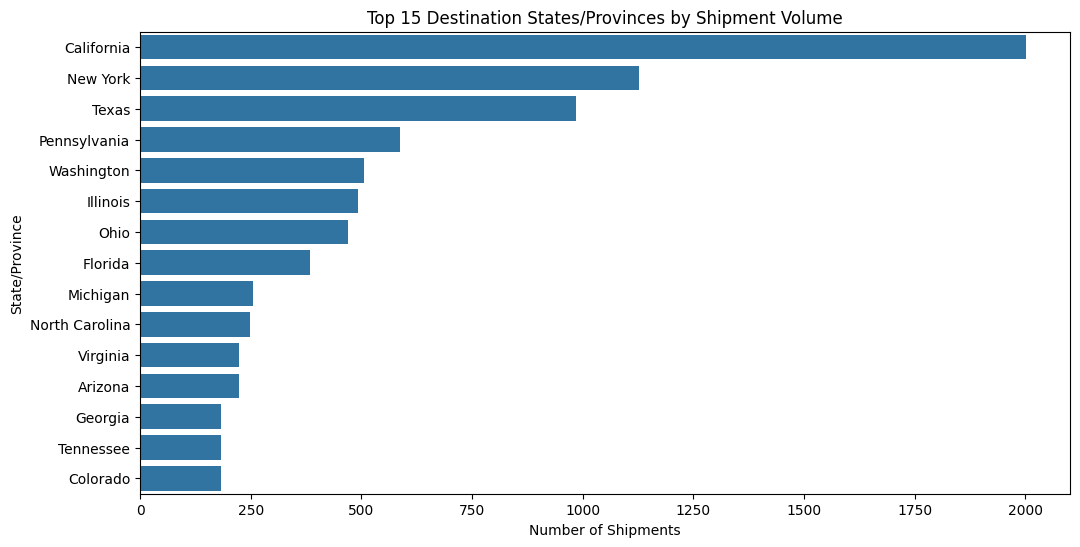

In [42]:
top_states = state_distribution.head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_states,
    x="Shipments",
    y="State/Province"
)

plt.title("Top 15 Destination States/Provinces by Shipment Volume")
plt.xlabel("Number of Shipments")
plt.ylabel("State/Province")

plt.show()

In [43]:
df["Route Region"] = (
    df["Factory"] + " → " + df["Region"]
)

In [44]:
region_routes = (
    df.groupby("Route Region")
      .size()
      .reset_index(name="Shipments")
      .sort_values("Shipments", ascending=False)
)

region_routes.head(20)

,Route Region,Shipments
3,Lot's O' Nuts → Pacific,1813
0,Lot's O' Nuts → Atlantic,1661
19,Wicked Choccy's → Pacific,1342
2,Lot's O' Nuts → Interior,1321
16,Wicked Choccy's → Atlantic,1197
18,Wicked Choccy's → Interior,950
1,Lot's O' Nuts → Gulf,897
17,Wicked Choccy's → Gulf,663
4,Secret Factory → Atlantic,72
7,Secret Factory → Pacific,63


In [45]:
destination_bottlenecks = (
    df.groupby("State/Province")
      .agg(
          Total_Shipments=("Order ID", "count"),
          Total_Sales=("Sales", "sum"),
          Total_Units=("Units", "sum"),
          Total_Cost=("Cost", "sum"),
          Total_Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
      .sort_values("Total_Shipments", ascending=False)
)

destination_bottlenecks.head(15)

,State/Province,Total_Shipments,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit
5,California,2001,27917.40,7667,9437.98,18479.42
34,New York,1128,15541.03,4224,5318.59,10222.44
51,Texas,985,13416.09,3724,4506.56,8909.53
43,Pennsylvania,587,8027.03,2153,2801.56,5225.47
55,Washington,506,6921.15,1883,2354.51,4566.64
13,Illinois,492,6898.96,1845,2341.28,4557.68
39,Ohio,469,6768.95,1759,2355.92,4413.03
10,Florida,383,4804.02,1379,1596.91,3207.11
23,Michigan,255,3331.00,946,1094.79,2236.21
36,North Carolina,249,3450.86,983,1119.70,2331.16


In [46]:
destination_bottlenecks["Profit_Margin_%"] = (
    destination_bottlenecks["Total_Gross_Profit"]
    / destination_bottlenecks["Total_Sales"]
    * 100
)

destination_bottlenecks["Cost_Per_Shipment"] = (
    destination_bottlenecks["Total_Cost"]
    / destination_bottlenecks["Total_Shipments"]
)

destination_bottlenecks.head(15)

,State/Province,Total_Shipments,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Profit_Margin_%,Cost_Per_Shipment
5,California,2001,27917.40,7667,9437.98,18479.42,66.193199,4.716632
34,New York,1128,15541.03,4224,5318.59,10222.44,65.777107,4.715062
51,Texas,985,13416.09,3724,4506.56,8909.53,66.409289,4.575188
43,Pennsylvania,587,8027.03,2153,2801.56,5225.47,65.098424,4.772675
55,Washington,506,6921.15,1883,2354.51,4566.64,65.980942,4.653182
13,Illinois,492,6898.96,1845,2341.28,4557.68,66.063291,4.758699
39,Ohio,469,6768.95,1759,2355.92,4413.03,65.195193,5.023284
10,Florida,383,4804.02,1379,1596.91,3207.11,66.758881,4.169478
23,Michigan,255,3331.00,946,1094.79,2236.21,67.133293,4.293294
36,North Carolina,249,3450.86,983,1119.70,2331.16,67.553016,4.496787


In [47]:
factory_performance = (
    df.groupby("Factory")
      .agg(
          Shipments=("Order ID", "count"),
          Sales=("Sales", "sum"),
          Units=("Units", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Cost=("Cost", "sum")
      )
      .reset_index()
)

factory_performance

,Factory,Shipments,Sales,Units,Gross_Profit,Cost
0,Lot's O' Nuts,5692,76340.15,21412,52771.05,23569.10
1,Secret Factory,217,8587.50,884,4344.70,4242.80
2,Sugar Shack,33,220.98,107,121.23,99.75
3,The Other Factory,100,1282.25,388,152.25,1130.00
4,Wicked Choccy's,4152,55352.75,15863,36053.57,19299.18


In [48]:
factory_performance["Profit_Margin_%"] = (
    factory_performance["Gross_Profit"]
    / factory_performance["Sales"]
    * 100
)

factory_performance["Cost_Per_Shipment"] = (
    factory_performance["Cost"]
    / factory_performance["Shipments"]
)

factory_performance["Sales_Per_Shipment"] = (
    factory_performance["Sales"]
    / factory_performance["Shipments"]
)

factory_performance

,Factory,Shipments,Sales,Units,Gross_Profit,Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
0,Lot's O' Nuts,5692,76340.15,21412,52771.05,23569.10,69.126207,4.140741,13.411832
1,Secret Factory,217,8587.50,884,4344.70,4242.80,50.593304,19.552074,39.573733
2,Sugar Shack,33,220.98,107,121.23,99.75,54.860168,3.022727,6.696364
3,The Other Factory,100,1282.25,388,152.25,1130.00,11.873660,11.300000,12.822500
4,Wicked Choccy's,4152,55352.75,15863,36053.57,19299.18,65.134198,4.648165,13.331587


In [49]:
low_volume_routes = (
    route_business
    .sort_values("Total_Shipments", ascending=True)
)

low_volume_routes.head(10)

,Route State,Total_Shipments,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
63,Secret Factory → Connecticut,1,2.50,2,1.30,1.20,52.000000,1.20,2.50
56,Lot's O' Nuts → Wyoming,1,13.96,4,9.96,4.00,71.346705,4.00,13.96
98,Sugar Shack → Connecticut,1,3.98,2,2.48,1.50,62.311558,1.50,3.98
99,Sugar Shack → Delaware,1,4.50,3,2.10,2.40,46.666667,2.40,4.50
103,Sugar Shack → New Jersey,1,5.97,3,3.72,2.25,62.311558,2.25,5.97
110,Sugar Shack → Washington,1,1.99,1,1.24,0.75,62.311558,0.75,1.99
108,Sugar Shack → Tennessee,1,1.50,1,0.60,0.90,40.000000,0.90,1.50
107,Sugar Shack → Rhode Island,1,4.50,3,2.10,2.40,46.666667,2.40,4.50
91,Secret Factory → Utah,1,100.00,5,50.00,50.00,50.000000,50.00,100.00
92,Secret Factory → Vermont,1,7.50,6,3.90,3.60,52.000000,3.60,7.50


In [50]:
route_performance = (
    df.groupby("Route State")
      .agg(
          Shipments=("Order ID", "count"),
          Sales=("Sales", "sum"),
          Units=("Units", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Cost=("Cost", "sum"),
          Avg_Lead_Time=("Lead Time", "mean")
      )
      .reset_index()
)

route_performance["Profit_Margin_%"] = (
    route_performance["Gross_Profit"]
    / route_performance["Sales"]
    * 100
)

route_performance["Cost_Per_Shipment"] = (
    route_performance["Cost"]
    / route_performance["Shipments"]
)

route_performance["Sales_Per_Shipment"] = (
    route_performance["Sales"]
    / route_performance["Shipments"]
)

route_performance.head(10)

,Route State,Shipments,Sales,Units,Gross_Profit,Cost,Avg_Lead_Time,Profit_Margin_%,Cost_Per_Shipment,Sales_Per_Shipment
0,Lot's O' Nuts → Alabama,34,475.61,133,326.91,148.7,1295.205882,68.734888,4.373529,13.988529
1,Lot's O' Nuts → Alberta,16,204.32,57,141.42,62.9,1273.875000,69.214957,3.931250,12.770000
2,Lot's O' Nuts → Arizona,111,1468.05,411,1013.15,454.9,1306.198198,69.013317,4.098198,13.225676
3,Lot's O' Nuts → Arkansas,31,434.69,122,299.69,135.0,1285.354839,68.943385,4.354839,14.022258
4,Lot's O' Nuts → British Columbia,18,253.40,71,173.80,79.6,1273.777778,68.587214,4.422222,14.077778
5,Lot's O' Nuts → California,1125,15044.90,4221,10401.00,4643.9,1316.910222,69.133062,4.127911,13.373244
6,Lot's O' Nuts → Colorado,103,1447.66,405,999.06,448.6,1347.533981,69.012061,4.355340,14.054951
7,Lot's O' Nuts → Connecticut,47,523.59,147,362.29,161.3,1420.553191,69.193453,3.431915,11.140213
8,Lot's O' Nuts → Delaware,43,631.59,177,436.19,195.4,1273.302326,69.062208,4.544186,14.688140
9,Lot's O' Nuts → District of Columbia,8,126.00,35,85.30,40.7,1365.875000,67.698413,5.087500,15.750000


In [51]:
correlation_data = df[
    [
        "Sales",
        "Units",
        "Gross Profit",
        "Cost",
        "Lead Time"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Sales,Units,Gross Profit,Cost,Lead Time
Sales,1.000000,0.729347,0.976404,0.958986,-0.005438
Units,0.729347,1.000000,0.815820,0.563344,-0.006702
Gross Profit,0.976404,0.815820,1.000000,0.875144,-0.003305
Cost,0.958986,0.563344,0.875144,1.000000,-0.007846
Lead Time,-0.005438,-0.006702,-0.003305,-0.007846,1.000000


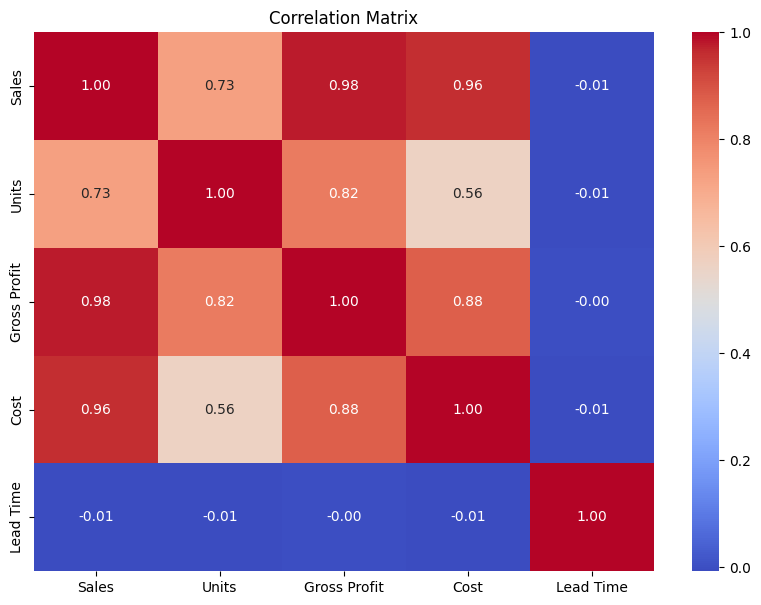

In [52]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [53]:
route_candidates = route_performance[
    [
        "Route State",
        "Shipments",
        "Sales",
        "Gross_Profit",
        "Cost",
        "Profit_Margin_%",
        "Cost_Per_Shipment",
        "Avg_Lead_Time"
    ]
].copy()

route_candidates.sort_values(
    "Cost_Per_Shipment",
    ascending=False
).head(10)

,Route State,Shipments,Sales,Gross_Profit,Cost,Profit_Margin_%,Cost_Per_Shipment,Avg_Lead_Time
59,Secret Factory → Arizona,5,640.00,320.00,320.0,50.000000,64.000000,1127.400000
77,Secret Factory → Nevada,2,202.50,101.30,101.2,50.024691,50.600000,1091.000000
91,Secret Factory → Utah,1,100.00,50.00,50.0,50.000000,50.000000,1275.000000
58,Secret Factory → Alberta,2,180.00,90.00,90.0,50.000000,45.000000,1274.500000
84,Secret Factory → Oregon,2,180.00,90.00,90.0,50.000000,45.000000,1271.500000
95,Secret Factory → Wisconsin,5,415.00,207.80,207.2,50.072289,41.440000,1346.400000
75,Secret Factory → Mississippi,1,80.00,40.00,40.0,50.000000,40.000000,908.000000
64,Secret Factory → Delaware,1,60.00,30.00,30.0,50.000000,30.000000,909.000000
83,Secret Factory → Ohio,13,768.75,384.95,383.8,50.074797,29.523077,1301.230769
86,Secret Factory → Quebec,2,100.00,50.00,50.0,50.000000,25.000000,1273.500000


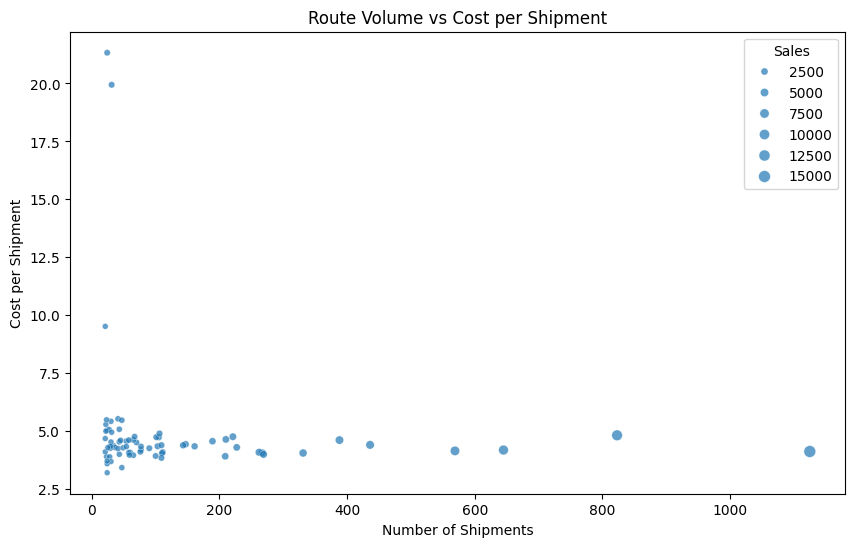

In [54]:
top_route_scatter = route_performance[
    route_performance["Shipments"] >= 20
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=top_route_scatter,
    x="Shipments",
    y="Cost_Per_Shipment",
    size="Sales",
    alpha=0.7
)

plt.title("Route Volume vs Cost per Shipment")
plt.xlabel("Number of Shipments")
plt.ylabel("Cost per Shipment")

plt.show()

In [55]:
df.to_csv(
    "../data/processed_shipping_data.csv",
    index=False
)

In [62]:
route_performance.to_csv(
    "../data/route_performance.csv",
    index=False
)

In [56]:
cost_threshold = df["Cost"].quantile(0.75)

print("75th percentile cost:", cost_threshold)

75th percentile cost: 5.7


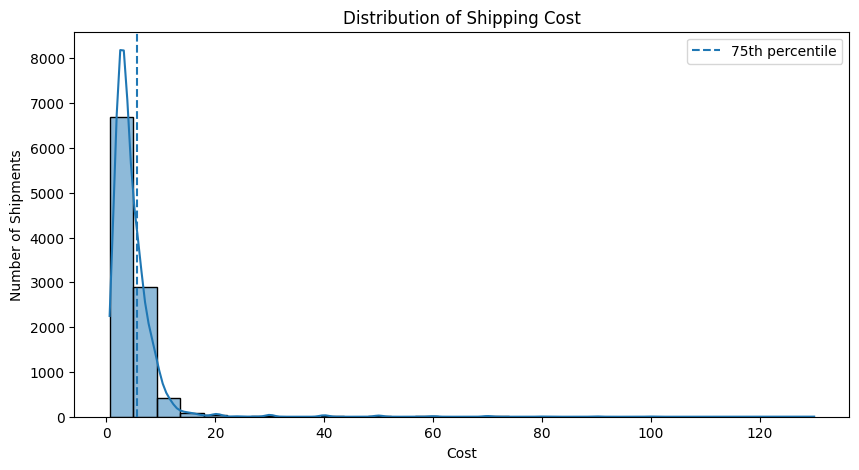

In [57]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Cost"],
    bins=30,
    kde=True
)

plt.axvline(
    cost_threshold,
    linestyle="--",
    label="75th percentile"
)

plt.title("Distribution of Shipping Cost")
plt.xlabel("Cost")
plt.ylabel("Number of Shipments")
plt.legend()

plt.show()

In [58]:
df["High_Cost"] = (
    df["Cost"] >= cost_threshold
).astype(int)

In [59]:
df["High_Cost"].value_counts()

High_Cost
0    7428
1    2766
Name: count, dtype: int64

In [60]:
df["High_Cost"].value_counts(normalize=True) * 100

High_Cost
0    72.866392
1    27.133608
Name: proportion, dtype: float64

In [61]:
df = engineer_features(df)

In [62]:
df[
    [
        "Product Name",
        "Factory",
        "Factory Latitude",
        "Factory Longitude",
        "Route State",
        "Route Region",
        "High_Cost"
    ]
].head()

,Product Name,Factory,Factory Latitude,Factory Longitude,Route State,Route Region,High_Cost
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Texas,Wicked Choccy's → Interior,0
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Illinois,Wicked Choccy's → Interior,0
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior,0
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior,0
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Pennsylvania,Wicked Choccy's → Atlantic,0


In [63]:
print("Unmapped factories:", df["Factory"].isnull().sum())
print("High-cost shipments:", df["High_Cost"].sum())
print("Normal-cost shipments:", (df["High_Cost"] == 0).sum())

Unmapped factories: 0
High-cost shipments: 2766
Normal-cost shipments: 7428


In [64]:
ml_features = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units",
    "Sales"
]

X = df[ml_features].copy()
y = df["High_Cost"].copy()

In [65]:
ml_features = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units",
    "Sales"
]

X = df[ml_features].copy()
y = df["High_Cost"].copy()

In [66]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10194, 8)
Target shape: (10194,)


In [67]:
X.head()

,Ship Mode,Factory,State/Province,Region,Division,Product Name,Units,Sales
0,Standard Class,Wicked Choccy's,Texas,Interior,Chocolate,Wonka Bar - Milk Chocolate,2,6.50
1,Standard Class,Wicked Choccy's,Illinois,Interior,Chocolate,Wonka Bar - Triple Dazzle Caramel,2,7.50
2,Standard Class,Lot's O' Nuts,Illinois,Interior,Chocolate,Wonka Bar - Nutty Crunch Surprise,3,10.47
3,Standard Class,Lot's O' Nuts,Illinois,Interior,Chocolate,Wonka Bar -Scrumdiddlyumptious,3,10.80
4,Standard Class,Wicked Choccy's,Pennsylvania,Atlantic,Chocolate,Wonka Bar - Triple Dazzle Caramel,3,11.25


In [68]:
y.value_counts()

High_Cost
0    7428
1    2766
Name: count, dtype: int64

In [69]:
X.dtypes

Ship Mode             str
Factory               str
State/Province        str
Region                str
Division              str
Product Name          str
Units               int64
Sales             float64
dtype: object

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [73]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8155
Testing samples: 2039


SECTION: Machine Learning → Preprocessing

In [74]:
categorical_features = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name"
]

numerical_features = [
    "Units",
    "Sales"
]

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [78]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [79]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [80]:
y_pred_lr = logistic_model.predict(X_test)

In [81]:
y_pred_lr[:20]

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

SECTION: Machine Learning → Model Evaluation

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [83]:
print("Logistic Regression")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression
-------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [84]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       1.00      1.00      1.00       553

    accuracy                           1.00      2039
   macro avg       1.00      1.00      1.00      2039
weighted avg       1.00      1.00      1.00      2039



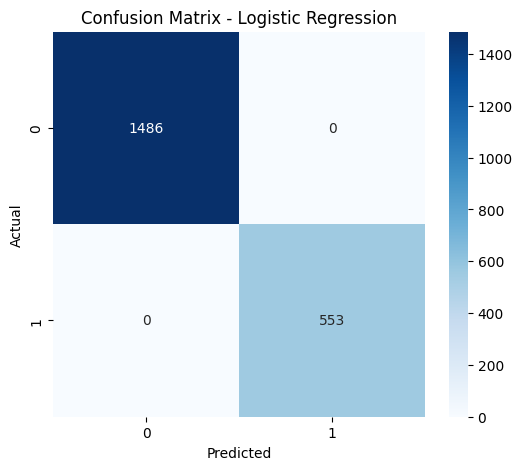

In [85]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [88]:
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [89]:
y_pred_rf = random_forest_model.predict(X_test)

In [90]:
print("Random Forest")
print("-------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
-------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [91]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       1.00      1.00      1.00       553

    accuracy                           1.00      2039
   macro avg       1.00      1.00      1.00      2039
weighted avg       1.00      1.00      1.00      2039



SECTION: Machine Learning → Model Comparison

In [92]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


SECTION: Machine Learning → Target Analysis

In [93]:
cost_threshold = df["Cost"].quantile(0.75)

print("Cost threshold:", cost_threshold)

Cost threshold: 5.7


In [94]:


print("\nTarget distribution:")
print(df["High_Cost"].value_counts())

print("\nTarget percentage:")
print(df["High_Cost"].value_counts(normalize=True) * 100)


Target distribution:
High_Cost
0    7428
1    2766
Name: count, dtype: int64

Target percentage:
High_Cost
0    72.866392
1    27.133608
Name: proportion, dtype: float64


In [95]:
df.groupby("High_Cost")["Cost"].agg(
    ["count", "min", "max", "mean", "median"]
)

,count,min,max,mean,median
High_Cost,,,,,
0,7428,0.6,5.6,3.081671,3.0
1,2766,5.7,130.0,9.201077,7.7


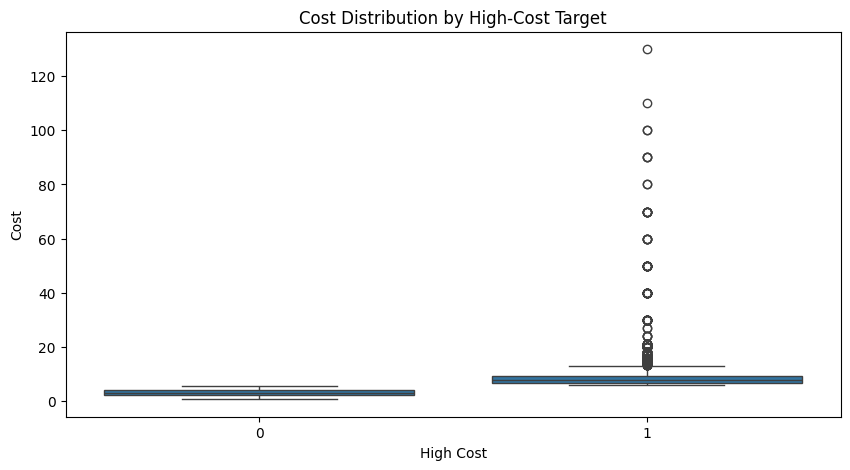

In [96]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="High_Cost",
    y="Cost"
)

plt.title("Cost Distribution by High-Cost Target")
plt.xlabel("High Cost")
plt.ylabel("Cost")

plt.show()

In [97]:
df[
    [
        "Sales",
        "Units",
        "Cost",
        "Gross Profit"
    ]
].corr()

,Sales,Units,Cost,Gross Profit
Sales,1.000000,0.729347,0.958986,0.976404
Units,0.729347,1.000000,0.563344,0.815820
Cost,0.958986,0.563344,1.000000,0.875144
Gross Profit,0.976404,0.815820,0.875144,1.000000


SECTION: Machine Learning → Leakage / Feature Analysis

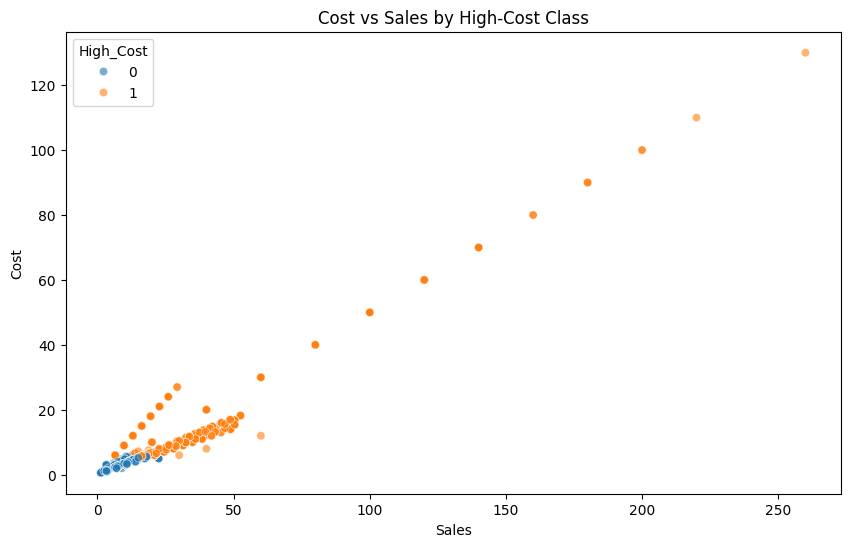

In [98]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Cost",
    hue="High_Cost",
    alpha=0.6
)

plt.title("Cost vs Sales by High-Cost Class")
plt.xlabel("Sales")
plt.ylabel("Cost")

plt.show()

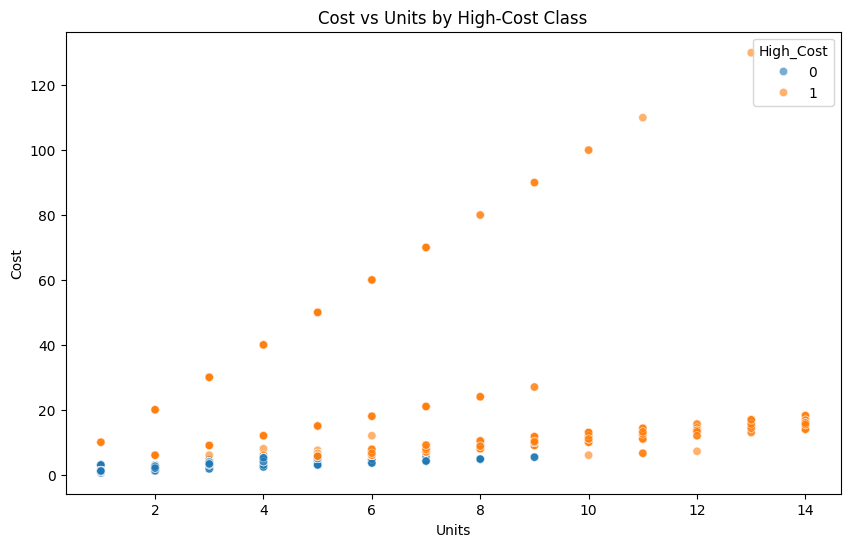

In [99]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Units",
    y="Cost",
    hue="High_Cost",
    alpha=0.6
)

plt.title("Cost vs Units by High-Cost Class")
plt.xlabel("Units")
plt.ylabel("Cost")

plt.show()

In [100]:
sales_cost_check = (
    df.groupby("Sales")["Cost"]
      .nunique()
      .value_counts()
      .sort_index()
)

sales_cost_check

Cost
1    52
2    33
3     2
4     1
Name: count, dtype: int64

In [101]:
df.groupby("Sales")["Cost"].nunique().max()

np.int64(4)

In [102]:
sales_cost_examples = (
    df.groupby("Sales")["Cost"]
      .nunique()
      .sort_values(ascending=False)
)

sales_cost_examples.head(10)

Sales
7.50     4
11.25    3
15.00    3
1.50     2
4.50     2
6.50     2
3.60     2
3.25     2
7.20     2
9.75     2
Name: Cost, dtype: int64

In [104]:
sales_value = sales_cost_examples.index[0]

df[
    df["Sales"] == sales_value
][
    [
        "Sales",
        "Cost",
        "High_Cost",
        "Product Name",
        "Units",
        "Ship Mode",
        "Factory"
    ]
]

,Sales,Cost,High_Cost,Product Name,Units,Ship Mode,Factory
1,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's
6,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's
16,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's
68,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,First Class,Wicked Choccy's
71,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,First Class,Wicked Choccy's
...,...,...,...,...,...,...,...
10154,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's
10155,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's
10156,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's
10181,7.5,2.6,0,Wonka Bar - Triple Dazzle Caramel,2,Standard Class,Wicked Choccy's


In [105]:
df.groupby("High_Cost")[
    ["Sales", "Units", "Cost"]
].mean()

,Sales,Units,Cost
High_Cost,,,
0,9.531101,2.736537,3.081671
1,25.663995,6.625813,9.201077


In [106]:
df.groupby("High_Cost")[
    ["Sales", "Units", "Cost"]
].median()

,Sales,Units,Cost
High_Cost,,,
0,9.75,3.0,3.0
1,22.50,6.0,7.7


SECTION: Machine Learning → Feature Experiment

In [107]:
ml_features_categorical = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name"
]

X_cat = df[ml_features_categorical].copy()
y_cat = df["High_Cost"].copy()

In [108]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y_cat,
    test_size=0.20,
    random_state=42,
    stratify=y_cat
)

In [109]:
preprocessor_cat = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ml_features_categorical
        )
    ]
)

In [110]:
logistic_cat = Pipeline(
    steps=[
        ("preprocessor", preprocessor_cat),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [111]:
logistic_cat.fit(
    X_train_cat,
    y_train_cat
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [112]:
y_pred_cat = logistic_cat.predict(X_test_cat)

In [113]:
print("Accuracy :", accuracy_score(y_test_cat, y_pred_cat))
print("Precision:", precision_score(y_test_cat, y_pred_cat))
print("Recall   :", recall_score(y_test_cat, y_pred_cat))
print("F1 Score :", f1_score(y_test_cat, y_pred_cat))

Accuracy : 0.7435017165277097
Precision: 0.8947368421052632
Recall   : 0.06148282097649186
F1 Score : 0.11505922165820642


In [114]:
model_comparison_extended = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression - Categorical Only"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_cat, y_pred_cat)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test_cat, y_pred_cat)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test_cat, y_pred_cat)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test_cat, y_pred_cat)
    ]
})

model_comparison_extended

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,Logistic Regression - Categorical Only,0.743502,0.894737,0.061483,0.115059


In [115]:
ml_features_sales = ["Sales"]

X_sales = df[ml_features_sales].copy()
y_sales = df["High_Cost"].copy()

X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales,
    y_sales,
    test_size=0.20,
    random_state=42,
    stratify=y_sales
)

In [116]:
sales_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

sales_model.fit(X_train_sales, y_train_sales)

y_pred_sales = sales_model.predict(X_test_sales)

In [117]:
print("Sales Only")
print("Accuracy :", accuracy_score(y_test_sales, y_pred_sales))
print("Precision:", precision_score(y_test_sales, y_pred_sales))
print("Recall   :", recall_score(y_test_sales, y_pred_sales))
print("F1 Score :", f1_score(y_test_sales, y_pred_sales))

Sales Only
Accuracy : 0.918097106424718
Precision: 0.8339100346020761
Recall   : 0.8716094032549728
F1 Score : 0.852343059239611


In [118]:
ml_features_units = ["Units"]

X_units = df[ml_features_units].copy()
y_units = df["High_Cost"].copy()

X_train_units, X_test_units, y_train_units, y_test_units = train_test_split(
    X_units,
    y_units,
    test_size=0.20,
    random_state=42,
    stratify=y_units
)

In [119]:
units_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

units_model.fit(X_train_units, y_train_units)

y_pred_units = units_model.predict(X_test_units)

In [120]:
print("Units Only")
print("Accuracy :", accuracy_score(y_test_units, y_pred_units))
print("Precision:", precision_score(y_test_units, y_pred_units))
print("Recall   :", recall_score(y_test_units, y_pred_units))
print("F1 Score :", f1_score(y_test_units, y_pred_units))

Units Only
Accuracy : 0.9406571848945562
Precision: 0.839622641509434
Recall   : 0.9656419529837251
F1 Score : 0.8982338099243061


SECTION: ML — Cost Prediction

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [122]:
ml_features_reg = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units",
    "Sales"
]

X_reg = df[ml_features_reg].copy()
y_reg = df["Cost"].copy()

In [123]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [124]:
categorical_features_reg = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name"
]

numerical_features_reg = [
    "Units",
    "Sales"
]


In [125]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_reg
        ),
        (
            "num",
            StandardScaler(),
            numerical_features_reg
        )
    ]
)

In [126]:
linear_model = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train_reg, y_train_reg)

y_pred_linear = linear_model.predict(X_test_reg)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_linear))
print("RMSE:", mean_squared_error(y_test_reg, y_pred_linear) ** 0.5)
print("R²  :", r2_score(y_test_reg, y_pred_linear))

Linear Regression
MAE : 0.19054920817306198
RMSE: 0.5107525463737967
R²  : 0.9864010396988402


In [127]:
random_forest_reg = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

random_forest_reg.fit(X_train_reg, y_train_reg)

y_pred_rf = random_forest_reg.predict(X_test_reg)

print("Random Forest Regression")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf))
print("RMSE:", mean_squared_error(y_test_reg, y_pred_rf) ** 0.5)
print("R²  :", r2_score(y_test_reg, y_pred_rf))

Random Forest Regression
MAE : 0.00636054438451208
RMSE: 0.08486646953912517
R²  : 0.9996245458607732


SECTION: ML — Model Comparison

In [129]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_linear),
        mean_absolute_error(y_test_reg, y_pred_rf)
    ],
    "RMSE": [
        mean_squared_error(y_test_reg, y_pred_linear) ** 0.5,
        mean_squared_error(y_test_reg, y_pred_rf) ** 0.5
    ],
    "R2": [
        r2_score(y_test_reg, y_pred_linear),
        r2_score(y_test_reg, y_pred_rf)
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.190549,0.510753,0.986401
1,Random Forest Regression,0.006361,0.084866,0.999625


In [137]:
prediction_check = pd.DataFrame({
    "Actual Cost": y_test_reg.values,
    "Predicted Cost": y_pred_rf
})

prediction_check.head(20)

,Actual Cost,Predicted Cost
0,3.6,3.6
1,1.3,1.3
2,3.9,3.9
3,4.8,4.8
4,3.3,3.3
5,9.6,9.6
6,10.8,10.8
7,3.3,3.3
8,2.0,2.0
9,2.4,2.4


SECTION: ML — Error Analysis

In [138]:
prediction_check = pd.DataFrame({
    "Actual Cost": y_test_reg.values,
    "Predicted Cost": y_pred_rf
})

prediction_check.head(20)

,Actual Cost,Predicted Cost
0,3.6,3.6
1,1.3,1.3
2,3.9,3.9
3,4.8,4.8
4,3.3,3.3
5,9.6,9.6
6,10.8,10.8
7,3.3,3.3
8,2.0,2.0
9,2.4,2.4


In [139]:
prediction_check["Absolute Error"] = (
    prediction_check["Actual Cost"]
    - prediction_check["Predicted Cost"]
).abs()

prediction_check.head(20)

,Actual Cost,Predicted Cost,Absolute Error
0,3.6,3.6,1.421085e-14
1,1.3,1.3,5.107026e-15
2,3.9,3.9,1.199041e-14
3,4.8,4.8,1.776357e-14
4,3.3,3.3,8.881784e-15
5,9.6,9.6,3.375078e-14
6,10.8,10.8,2.131628e-14
7,3.3,3.3,8.881784e-15
8,2.0,2.0,0.000000e+00
9,2.4,2.4,1.110223e-14


In [140]:
largest_errors = prediction_check.sort_values(
    "Absolute Error",
    ascending=False
)

largest_errors.head(10)

,Actual Cost,Predicted Cost,Absolute Error
747,90.0,92.5000,2.5000
1594,27.0,24.9303,2.0697
145,5.6,4.4408,1.1592
1333,16.8,16.1969,0.6031
754,70.0,70.6000,0.6000
1674,16.8,16.2035,0.5965
1424,6.6,6.0398,0.5602
331,15.6,15.0940,0.5060
1834,6.6,6.1088,0.4912
81,16.8,16.3113,0.4887


In [141]:
print(prediction_check.columns)

Index(['Actual Cost', 'Predicted Cost', 'Absolute Error'], dtype='str')


SECTION: ML — Cross Validation

In [142]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_forest_reg,
    X_reg,
    y_reg,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:")
print(cv_scores)

print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

Cross-validation R² scores:
[0.98720732 0.99964609 0.97663714 0.99978099 0.99918944]
Mean CV R²: 0.9924921964106515
Std CV R²: 0.009257110673449514


SECTION: ML — Feature Importance

In [143]:
# Get the fitted preprocessing pipeline
preprocessor_fitted = random_forest_reg.named_steps["preprocessor"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Random Forest feature importance
importances = random_forest_reg.named_steps["regressor"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
91,num__Sales,0.899284
90,num__Units,0.049829
73,cat__Division_Other,0.032310
79,cat__Product Name_Kazookles,0.008836
7,cat__Factory_The Other Factory,0.003430
86,cat__Product Name_Wonka Bar - Nutty Crunch Sur...,0.001716
84,cat__Product Name_Wonka Bar - Fudge Mallows,0.000680
52,cat__State/Province_Pennsylvania,0.000634
72,cat__Division_Chocolate,0.000399
87,cat__Product Name_Wonka Bar - Triple Dazzle Ca...,0.000363


SECTION: ML — Feature Importance Visualization

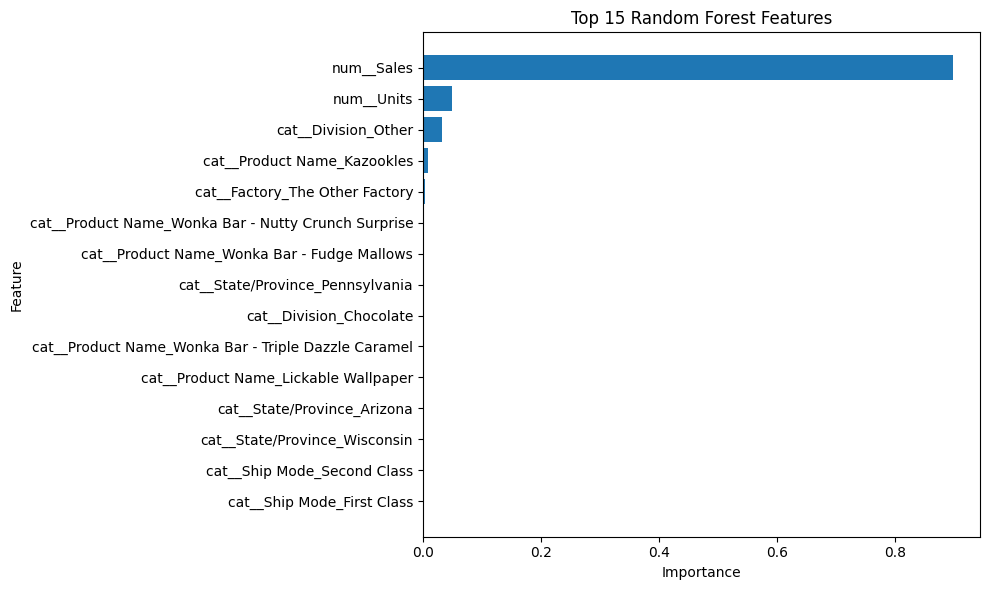

In [144]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.tight_layout()
plt.show()

SECTION: ML — Regression Without Sales

In [145]:
ml_features_no_sales = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units"
]

X_no_sales = df[ml_features_no_sales].copy()
y_no_sales = df["Cost"].copy()

In [146]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sales,
    y_no_sales,
    test_size=0.20,
    random_state=42
)

In [147]:
categorical_features_ns = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name"
]

numerical_features_ns = [
    "Units"
]

preprocessor_ns = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_ns
        ),
        (
            "num",
            StandardScaler(),
            numerical_features_ns
        )
    ]
)

In [148]:
random_forest_no_sales = Pipeline([
    ("preprocessor", preprocessor_ns),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

random_forest_no_sales.fit(X_train_ns, y_train_ns)

y_pred_ns = random_forest_no_sales.predict(X_test_ns)

In [149]:
print("Random Forest — Without Sales")

print("MAE :", mean_absolute_error(y_test_ns, y_pred_ns))

print(
    "RMSE:",
    mean_squared_error(y_test_ns, y_pred_ns) ** 0.5
)

print(
    "R²  :",
    r2_score(y_test_ns, y_pred_ns)
)

Random Forest — Without Sales
MAE : 0.008266380578724914
RMSE: 0.09784433837722384
R²  : 0.9995009362486728


In [150]:
ml_features_no_sales = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units"
]

X_no_sales = df[ml_features_no_sales].copy()
y_no_sales = df["Cost"].copy()

In [151]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sales,
    y_no_sales,
    test_size=0.20,
    random_state=42
)

In [152]:
categorical_features_ns = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name"
]

numerical_features_ns = [
    "Units"
]

preprocessor_ns = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_ns
        ),
        (
            "num",
            StandardScaler(),
            numerical_features_ns
        )
    ]
)

In [153]:
random_forest_no_sales = Pipeline([
    ("preprocessor", preprocessor_ns),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

random_forest_no_sales.fit(X_train_ns, y_train_ns)

y_pred_ns = random_forest_no_sales.predict(X_test_ns)

In [154]:
print("Random Forest — Without Sales")

print("MAE :", mean_absolute_error(y_test_ns, y_pred_ns))

print(
    "RMSE:",
    mean_squared_error(y_test_ns, y_pred_ns) ** 0.5
)

print(
    "R²  :",
    r2_score(y_test_ns, y_pred_ns)
)

Random Forest — Without Sales
MAE : 0.008266380578724914
RMSE: 0.09784433837722384
R²  : 0.9995009362486728


In [155]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - With Sales",
        "Random Forest - Without Sales"
    ],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_rf),
        mean_absolute_error(y_test_ns, y_pred_ns)
    ],
    "RMSE": [
        mean_squared_error(y_test_reg, y_pred_rf) ** 0.5,
        mean_squared_error(y_test_ns, y_pred_ns) ** 0.5
    ],
    "R2": [
        r2_score(y_test_reg, y_pred_rf),
        r2_score(y_test_ns, y_pred_ns)
    ]
})

final_model_comparison

,Model,MAE,RMSE,R2
0,Random Forest - With Sales,0.006361,0.084866,0.999625
1,Random Forest - Without Sales,0.008266,0.097844,0.999501


In [156]:
import joblib

In [157]:
joblib.dump(
    random_forest_reg,
    "../data/random_forest_cost_model.pkl"
)

['../data/random_forest_cost_model.pkl']

In [158]:
loaded_model = joblib.load(
    "../data/random_forest_cost_model.pkl"
)

test_prediction = loaded_model.predict(
    X_test_reg.iloc[:5]
)

print("Sample predictions:")
print(test_prediction)

Sample predictions:
[3.6 1.3 3.9 4.8 3.3]


In [159]:
# Test whether Ship Mode affects the Random Forest prediction

test_input = X_test_reg.iloc[[0]].copy()

print("Original input:")
print(test_input)

for mode in ["First Class", "Same Day", "Second Class", "Standard Class"]:
    test_case = test_input.copy()
    test_case["Ship Mode"] = mode

    prediction = random_forest_reg.predict(test_case)[0]

    print(f"{mode}: ${prediction:.4f}")

Original input:
     Ship Mode        Factory State/Province    Region   Division  \
6636  Same Day  Lot's O' Nuts           Ohio  Atlantic  Chocolate   

                   Product Name  Units  Sales  
6636  Wonka Bar - Fudge Mallows      3   10.8  
First Class: $3.6000
Same Day: $3.6000
Second Class: $3.6000
Standard Class: $3.6000


In [162]:
print("Pipeline steps:")
for name, step in random_forest_reg.named_steps.items():
    print(name, "->", type(step).__name__)

Pipeline steps:
preprocessor -> ColumnTransformer
regressor -> RandomForestRegressor


In [163]:
# Get feature names from the preprocessing step
feature_names = (
    random_forest_reg
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Find the Random Forest model automatically
rf_model = None

for name, step in random_forest_reg.named_steps.items():
    if hasattr(step, "feature_importances_"):
        rf_model = step
        print("Random Forest step found:", name)
        break

if rf_model is None:
    print("No model with feature_importances_ was found.")
else:
    importances = rf_model.feature_importances_

    ship_mode_features = [
        (feature, importance)
        for feature, importance in zip(feature_names, importances)
        if "Ship Mode" in feature
    ]

    print("\nShip Mode feature importance:")
    for feature, importance in ship_mode_features:
        print(f"{feature}: {importance:.6f}")

Random Forest step found: regressor

Ship Mode feature importance:
cat__Ship Mode_First Class: 0.000169
cat__Ship Mode_Same Day: 0.000000
cat__Ship Mode_Second Class: 0.000191
cat__Ship Mode_Standard Class: 0.000086


In [165]:
import pandas as pd
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

df_test = pd.read_csv(
    PROJECT_ROOT / "data" / "processed_shipping_data.csv"
)

model = joblib.load(
    PROJECT_ROOT / "data" / "random_forest_cost_model.pkl"
)

ml_features_reg = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units",
    "Sales"
]

shipping_modes = [
    "First Class",
    "Same Day",
    "Second Class",
    "Standard Class"
]

test_input = df_test[ml_features_reg].iloc[[0]].copy()

results = []

for mode in shipping_modes:

    test_case = test_input.copy()
    test_case["Ship Mode"] = mode

    prediction = model.predict(test_case)[0]

    results.append({
        "Ship Mode": mode,
        "Predicted Cost": prediction
    })

ship_mode_results = pd.DataFrame(results)

ship_mode_results

,Ship Mode,Predicted Cost
0,First Class,2.28
1,Same Day,2.28
2,Second Class,2.28
3,Standard Class,2.28


In [167]:
import pandas as pd
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

df_test = pd.read_csv(
    PROJECT_ROOT / "data" / "processed_shipping_data.csv"
)

model = joblib.load(
    PROJECT_ROOT / "data" / "random_forest_cost_model.pkl"
)

ml_features_reg = [
    "Ship Mode",
    "Factory",
    "State/Province",
    "Region",
    "Division",
    "Product Name",
    "Units",
    "Sales"
]

shipping_modes = [
    "First Class",
    "Same Day",
    "Second Class",
    "Standard Class"
]

# Take one real shipment
test_input = df_test[ml_features_reg].iloc[[0]].copy()

results = []

for mode in shipping_modes:
    test_case = test_input.copy()
    test_case["Ship Mode"] = mode

    prediction = model.predict(test_case)[0]

    results.append({
        "Ship Mode": mode,
        "Predicted Cost": round(prediction, 4)
    })

ship_mode_results = pd.DataFrame(results)

print(ship_mode_results.to_string(index=False))

     Ship Mode  Predicted Cost
   First Class            2.28
      Same Day            2.28
  Second Class            2.28
Standard Class            2.28


In [166]:
# Show all features related to Ship Mode

feature_names = random_forest_reg.named_steps["preprocessor"].get_feature_names_out()
importances = random_forest_reg.named_steps["model"].feature_importances_

ship_mode_features = [
    (feature, importance)
    for feature, importance in zip(feature_names, importances)
    if "Ship Mode" in feature
]

ship_mode_features

KeyError: 'model'